<a href="https://colab.research.google.com/github/maurocollin/bigdata-saude-niteroi/blob/main/TRAB_PRONTO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Matéria: Tópicos de Big Data em Python
### TEMA:
### Análise de Indicadores de Saúde Municipal Pública e Privada: Previsão de Demandas por Bairro em Niterói-RJ

#### Integrantes:
* Hudson Mata Neves - Matrícula: 202402852175
* Mauro Henrique Collin Ferreira - Matrícula: 202403689601

Nesta fase inicial, centralizamos as dependências do projeto e estabelecemos o consumo de dados diretamente do repositório remoto via GitHub. Esta abordagem garante a reprodutibilidade técnica, permitindo que o estudo seja executado em qualquer ambiente sem dependência de arquivos locais. Além da ingestão, implementamos um diagnóstico de estrutura para auditar o volume de dados (linhas e colunas) e validar a tipagem das variáveis, assegurando a integridade da base antes das análises estatísticas.

In [13]:
# ==============================================================================
# ETAPA 1: SETUP E EXTRAÇÃO DOS DADOS
# ==============================================================================
# Instalação de bibliotecas extras necessárias para os mapas
!pip install geobr folium pyproj -q
import pandas as pd
import numpy as np
import unicodedata
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Configuração visual do Seaborn
sns.set_theme(style="whitegrid")

print("Iniciando a extração dos dados do GitHub...")

# URL base do repositório
url_base = 'https://raw.githubusercontent.com/maurocollin/bigdata-saude-niteroi/main/'

# Leitura dos arquivos CSV
df_pop = pd.read_csv(f'{url_base}Agregados_por_bairros_basico_BR.csv', sep=';', encoding='latin1', on_bad_lines='skip')
df_ubs = pd.read_csv(f'{url_base}Unidades_Basicas_de_Saude_UBS.csv', encoding='utf-8')
df_hosp = pd.read_csv(f'{url_base}Hospitais.csv', encoding='utf-8')
df_poli = pd.read_csv(f'{url_base}Policlinicas.csv', encoding='utf-8')
df_leitos = pd.read_csv(f'{url_base}CNES_Leitos_Niteroi.csv', encoding='utf-8')

print("✅ Bases carregadas com sucesso!")

# ==============================================================================
# DIAGNÓSTICO DE ESTRUTURA
# ==============================================================================
print("\n--- ESTRUTURA DAS BASES DE DADOS ---")

# Incluindo todas as bases carregadas para o diagnóstico completo
bases = {
    "População (IBGE)": df_pop,
    "UBS": df_ubs,
    "Hospitais": df_hosp,
    "Policlínicas": df_poli,
    "Leitos Hospitalares": df_leitos  # Adicionado agora
}

for nome, df in bases.items():
    print(f"\n📊 Base: {nome}")
    print(f"• Linhas: {df.shape[0]}")
    print(f"• Colunas: {df.shape[1]}")
    print("• Tipos de Variáveis:")
    print(df.dtypes)
    print("-" * 30)

Iniciando a extração dos dados do GitHub...
✅ Bases carregadas com sucesso!

--- ESTRUTURA DAS BASES DE DADOS ---

📊 Base: População (IBGE)
• Linhas: 17576
• Colunas: 30
• Tipos de Variáveis:
CD_BAIRRO      int64
NM_BAIRRO     object
CD_REGIAO      int64
NM_REGIAO     object
CD_UF          int64
NM_UF         object
CD_MUN         int64
NM_MUN        object
CD_DIST        int64
NM_DIST       object
CD_SUBDIST     int64
NM_SUBDIST    object
CD_NU         object
NM_NU         object
CD_AGLOM      object
NM_AGLOM      object
CD_RGINT       int64
NM_RGINT      object
CD_RGI         int64
NM_RGI        object
CD_CONCURB    object
NM_CONCURB    object
AREA_KM2      object
v0001         object
v0002         object
v0003         object
v0004         object
v0005         object
v0006         object
v0007         object
dtype: object
------------------------------

📊 Base: UBS
• Linhas: 11
• Colunas: 20
• Tipos de Variáveis:
fid            int64
cnes           int64
nome          object
nome_gen

Antes de proceder com a modelagem, nesta 2ª etapa, realizamos uma auditoria técnica para identificar inconsistências estruturais. Este relatório foca em dois pilares críticos: Valores Ausentes (Missing Data) e Registros Duplicados. A identificação precoce de dados nulos é vital para decidir entre estratégias de imputação ou exclusão, enquanto a remoção de duplicatas previne a inflação artificial de métricas e o sobreajuste (overfitting) do modelo preditivo.

In [14]:
# ==============================================================================
# ETAPA 2: RELATÓRIO DE QUALIDADE DE DADOS (NULOS E DUPLICADOS)
# ==============================================================================
print("\n--- RELATÓRIO DE QUALIDADE E INTEGRIDADE ---")

for nome, df in bases.items():
    total_nulos = df.isnull().sum().sum()
    total_duplicados = df.duplicated().sum()

    print(f"\n🔍 Análise da Base: {nome}")
    print(f"• Total de valores nulos encontrados: {total_nulos}")
    print(f"• Total de registros duplicados: {total_duplicados}")

    # Se houver nulos, detalha por coluna
    if total_nulos > 0:
        print("  ↳ Detalhamento de campos ausentes:")
        contagem_nulos = df.isnull().sum()
        print(contagem_nulos[contagem_nulos > 0])

    print("-" * 30)

# ==============================================================================
# ETAPA 2: TRANSFORMAÇÃO, LIMPEZA E REGRAS DE NEGÓCIO
# ==============================================================================

# 1. Função para normalizar strings
def normalizar_bairro(nome):
    if pd.isna(nome): return ''
    nome = str(nome).upper().strip()
    return ''.join(c for c in unicodedata.normalize('NFD', nome) if unicodedata.category(c) != 'Mn')

# Aplicando a normalização nas bases de saúde
df_hosp['BAIRRO_NORM'] = df_hosp['tx_bairro'].apply(normalizar_bairro)
df_poli['BAIRRO_NORM'] = df_poli['bairro'].apply(normalizar_bairro)
df_ubs['BAIRRO_NORM'] = df_ubs['bairro'].apply(normalizar_bairro)

# 2. Classificação Pública e Privada
def categorizar_gestao(nome):
    nome = str(nome).upper()
    palavras_publicas = ['MUNICIPAL', 'ESTADUAL', 'FEDERAL', 'UNIVERSITÁRIO', 'POLÍCIA MILITAR']
    excecoes_publicas = ['HOSPITAL PSIQUIÁTRICO DE JURUJUBA', 'HOSPITAL GETULIO VARGAS FILHO', 'HOSPITAL ORÊNCIO DE FREITAS']

    if any(palavra in nome for palavra in palavras_publicas) or any(exc in nome for exc in excecoes_publicas):
        return 'Pública'
    return 'Privada'

# Aplicando a categorização
df_hosp['Tipo_Unidade'] = df_hosp['tx_nome'].apply(categorizar_gestao)
df_poli['Tipo_Unidade'] = 'Pública' # Policlínicas são públicas
df_ubs['Tipo_Unidade'] = 'Pública'  # UBS são públicas

# 3. Limpando a base de População (IBGE)
df_niteroi = df_pop[df_pop['NM_MUN'] == 'Niterói'].copy()
df_niteroi['BAIRRO_NORM'] = df_niteroi['NM_BAIRRO'].apply(normalizar_bairro)
df_niteroi['POPULACAO'] = pd.to_numeric(df_niteroi['v0001'].astype(str).str.replace(',', '.'), errors='coerce')

print("✅ Padronização e classificação concluídas!")
# display(df_niteroi).head(5)



--- RELATÓRIO DE QUALIDADE E INTEGRIDADE ---

🔍 Análise da Base: População (IBGE)
• Total de valores nulos encontrados: 56585
• Total de registros duplicados: 0
  ↳ Detalhamento de campos ausentes:
NM_SUBDIST    14604
NM_NU         17169
NM_AGLOM      17411
NM_CONCURB     7401
dtype: int64
------------------------------

🔍 Análise da Base: UBS
• Total de valores nulos encontrados: 0
• Total de registros duplicados: 0
------------------------------

🔍 Análise da Base: Hospitais
• Total de valores nulos encontrados: 0
• Total de registros duplicados: 0
------------------------------

🔍 Análise da Base: Policlínicas
• Total de valores nulos encontrados: 0
• Total de registros duplicados: 0
------------------------------

🔍 Análise da Base: Leitos Hospitalares
• Total de valores nulos encontrados: 1762
• Total de registros duplicados: 0
  ↳ Detalhamento de campos ausentes:
REGSAUDE    194
MICR_REG    196
DISTRSAN    196
DISTRADM    196
ESFERA_A    196
RETENCAO    196
NATUREZA    196
NIV_H

Nesta 3ª etapa, aplicamos técnicas de estatística descritiva para sumarizar as características quantitativas do nosso conjunto de dados. O objetivo é compreender a distribuição da população e da infraestrutura de saúde entre os bairros de Niterói. Calculamos métricas de tendência central (média e mediana) para entender o comportamento típico, e métricas de dispersão (desvio padrão, valores mínimos e máximos) para identificar a variabilidade e a desigualdade na distribuição dos recursos municipais.

In [19]:
# ==============================================================================
# ETAPA 3: AGREGAÇÃO (GROUP BY) E CRUZAMENTO (MERGE)
# ==============================================================================

# 1. Consolidar todas as unidades em uma única lista
unidades = []
for _, row in df_hosp.iterrows(): unidades.append({'Bairro': row['BAIRRO_NORM'], 'Tipo': row['Tipo_Unidade']})
for _, row in df_poli.iterrows(): unidades.append({'Bairro': row['BAIRRO_NORM'], 'Tipo': row['Tipo_Unidade']})
for _, row in df_ubs.iterrows():  unidades.append({'Bairro': row['BAIRRO_NORM'], 'Tipo': row['Tipo_Unidade']})

df_unidades = pd.DataFrame(unidades)

# 2. Contar as unidades Públicas e Privadas por Bairro
df_saude_bairro = df_unidades.groupby(['Bairro', 'Tipo']).size().unstack(fill_value=0).reset_index()

# Garantir colunas
for col in ['Privada', 'Pública']:
    if col not in df_saude_bairro.columns: df_saude_bairro[col] = 0

df_saude_bairro['Total_Unidades'] = df_saude_bairro['Pública'] + df_saude_bairro['Privada']

# 3. Cruzamento (Merge) da População com a Saúde
df_pop_resumo = df_niteroi[['BAIRRO_NORM', 'NM_BAIRRO', 'POPULACAO']]
df_final = pd.merge(df_pop_resumo, df_saude_bairro, left_on='BAIRRO_NORM', right_on='Bairro', how='left')

# Tratando os nulos identificados na auditoria acima
df_final[['Privada', 'Pública', 'Total_Unidades']] = df_final[['Privada', 'Pública', 'Total_Unidades']].fillna(0)

print("✅ Tabela Analítica gerada com sucesso! Amostra dos 5 bairros mais populosos:")
display(df_final.sort_values(by='POPULACAO', ascending=False).head()[['NM_BAIRRO', 'POPULACAO', 'Privada', 'Pública', 'Total_Unidades']])

# ==============================================================================
# ESTATÍSTICA DESCRITIVA
# ==============================================================================
print("\n--- SUMÁRIO ESTATÍSTICO DOS INDICADORES ---")

colunas_analise = ['POPULACAO', 'Total_Unidades']

# 1. Gerando as estatísticas básicas
stats_descritiva = df_final[colunas_analise].describe().loc[['mean', '50%', 'std', 'min', 'max']]
stats_descritiva.index = ['Média', 'Mediana (50%)', 'Desvio Padrão', 'Mínimo', 'Máximo']

# 2. Funções de formatação customizadas
def formatar_pop_br(valor):
    # Formata como inteiro com ponto separador de milhar
    return f"{int(round(valor, 0)):,}".replace(",", ".")

def formatar_unidade_br(valor):
    # Mantém 2 casas decimais no padrão brasileiro
    return f"{valor:,.2f}".replace(",", "v").replace(".", ",").replace("v", ".")

# 3. Aplicando formatos diferentes para cada coluna
stats_view = stats_descritiva.copy()
stats_view['POPULACAO'] = stats_view['POPULACAO'].apply(formatar_pop_br)
stats_view['Total_Unidades'] = stats_view['Total_Unidades'].apply(formatar_unidade_br)

# Exibindo a tabela final
display(stats_view)

print("\n💡 ANÁLISE DOS RESULTADOS:")
for col in colunas_analise:
    media = df_final[col].mean()
    mediana = df_final[col].median()

    if col == 'POPULACAO':
        print(f"• {col}: Um bairro médio de Niterói possui {formatar_pop_br(media)} habitantes.")
    else:
        print(f"• {col}: Em média, os bairros possuem {media:.2f} unidades de saúde.")

✅ Tabela Analítica gerada com sucesso! Amostra dos 5 bairros mais populosos:


,NM_BAIRRO,POPULACAO,Privada,Pública,Total_Unidades
17,Icaraí,77247,1.0,0.0,1.0
15,Fonseca,46317,2.0,4.0,6.0
37,Santa Rosa,34112,1.0,1.0,2.0
2,Barreto,18699,1.0,5.0,6.0
32,Piratininga,18492,0.0,3.0,3.0



--- SUMÁRIO ESTATÍSTICO DOS INDICADORES ---


,POPULACAO,Total_Unidades
Média,9.264,"0,69"
Mediana (50%),5.809,"0,00"
Desvio Padrão,12.518,"1,50"
Mínimo,250,"0,00"
Máximo,77.247,"6,00"



💡 ANÁLISE DOS RESULTADOS:
• POPULACAO: Um bairro médio de Niterói possui 9.264 habitantes.
• Total_Unidades: Em média, os bairros possuem 0.69 unidades de saúde.


Análise Descritiva dos Dados

Após a consolidação e limpeza, realizamos a Análise Descritiva da base final. O objetivo aqui é entender o comportamento das variáveis quantitativas (como População e Total de Unidades de Saúde). Utilizamos os métodos .info() para verificar a completude do dataframe e .describe() para extrair estatísticas de resumo, como média, desvio padrão e quartis. Isso nos dá um panorama geral de como a infraestrutura de saúde está distribuída pela população de Niterói.

In [20]:
#####################################
#####################################
##  ADICIONADO AO CÓDIGO ANTERIOR  ##
#####################################
#####################################

#
# --- ANÁLISE DESCRITIVA DA BASE DE DADOS ---

print("Informações da Estrutura da Base de Dados:")
# O .info() mostra o número de linhas, colunas, valores não nulos e o tipo de dado de cada variável
df_final.info()

print("\n--------------------------------------------------\n")

print("Estatísticas Descritivas das Variáveis Numéricas:")
# O .describe() calcula a média, desvio padrão, mínimo, máximo e quartis
display(df_final.describe())

Informações da Estrutura da Base de Dados:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52 entries, 0 to 51
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   BAIRRO_NORM     52 non-null     object 
 1   NM_BAIRRO       52 non-null     object 
 2   POPULACAO       52 non-null     int64  
 3   Bairro          15 non-null     object 
 4   Privada         52 non-null     float64
 5   Pública         52 non-null     float64
 6   Total_Unidades  52 non-null     float64
dtypes: float64(3), int64(1), object(3)
memory usage: 3.0+ KB

--------------------------------------------------

Estatísticas Descritivas das Variáveis Numéricas:


,POPULACAO,Privada,Pública,Total_Unidades
count,52.000000,52.000000,52.000000,52.000000
mean,9264.403846,0.173077,0.519231,0.692308
std,12517.887910,0.473665,1.162998,1.502135
min,250.000000,0.000000,0.000000,0.000000
25%,3548.000000,0.000000,0.000000,0.000000
50%,5809.000000,0.000000,0.000000,0.000000
75%,9691.000000,0.000000,0.000000,1.000000
max,77247.000000,2.000000,5.000000,6.000000


Nesta etapa, analisamos a distribuição das unidades de saúde por Tipo de Gestão (Pública vs. Privada). Em projetos de Big Data voltados à gestão pública, entender a frequência relativa (proporção) é fundamental para identificar a dependência do município em relação à rede particular e o alcance da rede própria (SUS). Calculamos a frequência absoluta (contagem total) e a frequência relativa (porcentagem), fornecendo uma visão clara da infraestrutura assistencial de Niterói.

--------------------------------------------------
📊 1. COMPOSIÇÃO DA REDE DE SAÚDE EM NITERÓI
--------------------------------------------------


,Frequência Absoluta (Qtd),Frequência Relativa (%)
Tipo,,
Pública,30,"76,92%"
Privada,9,"23,08%"



💡 INSIGHTS DA REDE:
• Predomínio: Rede Pública (76,92% do total),
• STATUS: Rede pública majoritária na infraestrutura municipal.


--------------------------------------------------
🚨 2. IDENTIFICAÇÃO DE BAIRROS COM ALTA DEMANDA (OUTLIERS)
--------------------------------------------------
Critério: Bairros com mais de 17132 hab/unidade são considerados críticos.



,NM_BAIRRO,POPULACAO,Total_Unidades,Hab_por_Unidade,Z_Score
17,Icaraí,77.247,1.0,"77.247,00",3.64




📈 3. DISTRIBUIÇÃO E DISPERSÃO DOS DADOS


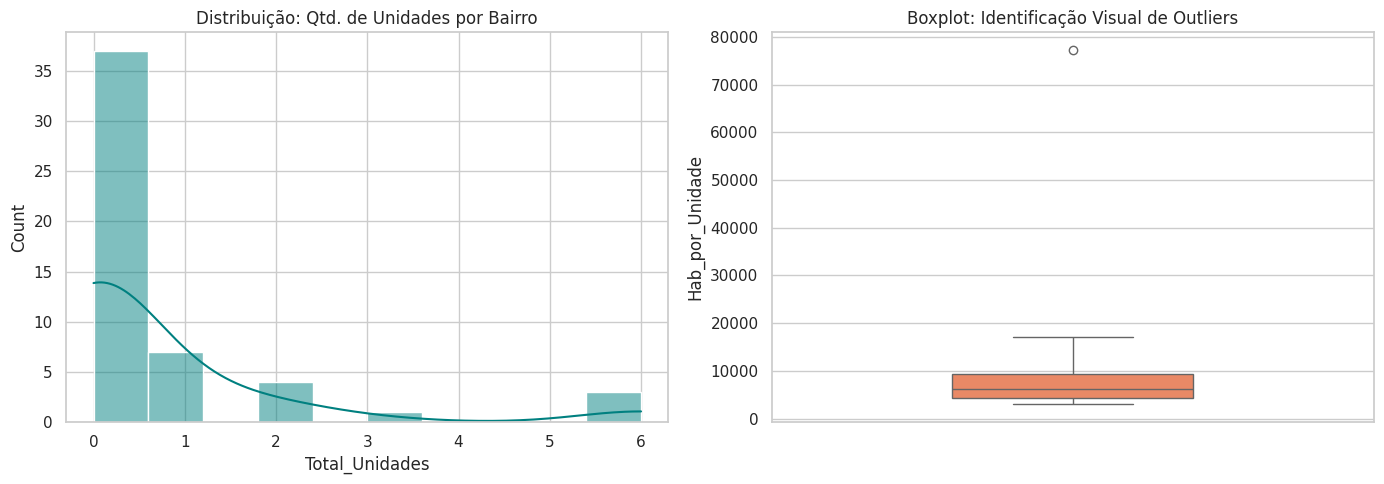

In [25]:
# ==============================================================================
# ETAPA 4: ANÁLISE DE COMPOSIÇÃO E IDENTIFICAÇÃO DE DÉFICITS (OUTLIERS)
# ==============================================================================

# --- 1. ANÁLISE DE COMPOSIÇÃO DA REDE (CATEGÓRICA) ---
print("-" * 50)
print("📊 1. COMPOSIÇÃO DA REDE DE SAÚDE EM NITERÓI")
print("-" * 50)

# (Cálculos de frequência permanecem iguais)
freq_absoluta = df_unidades['Tipo'].value_counts()
freq_relativa = df_unidades['Tipo'].value_counts(normalize=True) * 100
df_categorias = pd.DataFrame({'Frequência Absoluta (Qtd)': freq_absoluta, 'Frequência Relativa (%)': freq_relativa})

# Formatação visual da tabela de categorias
def formatar_porcentagem(valor): return f"{valor:.2f}%".replace(".", ",")
df_view_cat = df_categorias.copy()
df_view_cat['Frequência Relativa (%)'] = df_view_cat['Frequência Relativa (%)'].apply(formatar_porcentagem)

display(df_view_cat)

print("\n💡 INSIGHTS DA REDE:")
maior_cat = freq_absoluta.idxmax()
porcentagem_maior = freq_relativa.max()
print(f"• Predomínio: Rede {maior_cat} ({porcentagem_maior:.2f}% do total).".replace(".", ","))
if freq_relativa.get('Pública', 0) < 50:
    print("• ALERTA: Forte dependência do setor privado (Rede Pública < 50%).")
else:
    print("• STATUS: Rede pública majoritária na infraestrutura municipal.")

print("\n" + "="*50 + "\n") # Grande espaçador entre seções

# --- 2. ANÁLISE DE SUPERLOTAÇÃO E OUTLIERS (MÉTRICAS) ---
print("-" * 50)
print("🚨 2. IDENTIFICAÇÃO DE BAIRROS COM ALTA DEMANDA (OUTLIERS)")
print("-" * 50)

# Cálculos de métricas
df_final['Hab_por_Unidade'] = np.where(df_final['Total_Unidades'] > 0, df_final['POPULACAO'] / df_final['Total_Unidades'], np.nan)
df_validos = df_final.dropna(subset=['Hab_por_Unidade']).copy()
df_validos['Z_Score'] = stats.zscore(df_validos['Hab_por_Unidade'])

# Cálculo do Limite de Superlotação (IQR)
Q1 = df_validos['Hab_por_Unidade'].quantile(0.25)
Q3 = df_validos['Hab_por_Unidade'].quantile(0.75)
limite_superior = Q3 + 1.5 * (Q3 - Q1)

print(f"Critério: Bairros com mais de {int(limite_superior)} hab/unidade são considerados críticos.\n")

# Filtrando e formatando a tabela de outliers para exibição
df_outliers = df_validos[df_validos['Hab_por_Unidade'] > limite_superior][['NM_BAIRRO', 'POPULACAO', 'Total_Unidades', 'Hab_por_Unidade', 'Z_Score']].copy()

# Deixando a tabela de outliers bonita
df_outliers['POPULACAO'] = df_outliers['POPULACAO'].apply(lambda x: f"{int(x):,}".replace(",", "."))
df_outliers['Hab_por_Unidade'] = df_outliers['Hab_por_Unidade'].apply(lambda x: f"{x:,.2f}".replace(",", "v").replace(".", ",").replace("v", "."))
df_outliers['Z_Score'] = df_outliers['Z_Score'].round(2)

if not df_outliers.empty:
    display(df_outliers.sort_values(by='Z_Score', ascending=False))
else:
    print("✅ Nenhum bairro atingiu o nível crítico de superlotação pelos critérios estatísticos.")

print("\n" + "="*50 + "\n")

# --- 3. DISTRIBUIÇÃO VISUAL (GRÁFICOS) ---
print("📈 3. DISTRIBUIÇÃO E DISPERSÃO DOS DADOS")
# (O código dos gráficos permanece o mesmo, ele já gera uma visualização limpa)
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
sns.histplot(df_final['Total_Unidades'], bins=10, kde=True, color='teal')
plt.title('Distribuição: Qtd. de Unidades por Bairro')
plt.subplot(1, 2, 2)
sns.boxplot(y=df_validos['Hab_por_Unidade'], color='coral', width=0.4)
plt.title('Boxplot: Identificação Visual de Outliers')
plt.tight_layout()
plt.show()

Modelo de Regressão Linear para responder: "A quantidade de unidades de saúde acompanha o tamanho da população?". O cálculo dos **Resíduos** (Diferença entre o Real e o Previsto) nos mostra onde o planejamento urbano falhou: bairros com muita gente, que o modelo previu que deveriam ter unidades, mas na realidade possuem forte déficit.:

In [6]:
# ==============================================================================
# ETAPA 5: REGRESSÃO LINEAR INTERATIVA (DEMANDA X OFERTA)
# ==============================================================================

# 1. Preparação dos dados para a regressão
df_reg = df_final[df_final['POPULACAO'] > 0].copy()

X = df_reg[['POPULACAO']]
y = df_reg['Total_Unidades']

# 2. Treinando o modelo
modelo = LinearRegression().fit(X, y)
df_reg['PREDICAO'] = modelo.predict(X)
df_reg['RESIDUO'] = df_reg['Total_Unidades'] - df_reg['PREDICAO']

r2 = r2_score(y, df_reg['PREDICAO'])

# Bairros onde o modelo mais errou (Maior Déficit = Resíduo Negativo)
df_tendencia = df_reg.sort_values(by='POPULACAO')

# 3. Gráfico Interativo com Plotly
fig = px.scatter(
    df_reg,
    x='POPULACAO', y='Total_Unidades',
    color='RESIDUO',
    text='NM_BAIRRO', hover_name='NM_BAIRRO',
    hover_data={'POPULACAO': ':,.0f', 'Total_Unidades': True, 'RESIDUO': ':.2f'},
    title=f'<b>Niterói: Regressão População vs Infraestrutura (R²: {r2:.4f})</b><br><sup>Bairros em tons vermelhos indicam forte Déficit (Realidade < Previsto)</sup>',
    labels={'POPULACAO': 'População do Bairro', 'Total_Unidades': 'Unidades Reais', 'RESIDUO': 'Resíduo (Déficit)'},
    color_continuous_scale=px.colors.sequential.Reds_r,
    template='plotly_dark'
)

# Adicionando a linha de tendência
fig.add_trace(go.Scatter(x=df_tendencia['POPULACAO'], y=df_tendencia['PREDICAO'], mode='lines', name='Tendência', line=dict(color='cyan', width=2, dash='dot')))

fig.update_traces(textposition='top center', marker=dict(size=12, opacity=0.8))
fig.update_layout(height=650)
fig.show()

Para trazer uma perspectiva geográfica ao nosso problema de Big Data, utilizamos a biblioteca `Folium` aliada à conversão de coordenadas (`PyProj`). O mapa abaixo exibe de forma interativa a exata localização geográfica dos Hospitais, diferenciando a rede Pública (Vermelho) da rede Privada (Azul).

In [7]:
# ==============================================================================
# ETAPA 6: VISUALIZAÇÃO ESPACIAL - MAPA DE HOSPITAIS EM NITERÓI
# ==============================================================================
import folium
from pyproj import Transformer

print("Gerando Mapa Interativo Espacial...")

# Transformador de coordenadas UTM 23S para Lat/Lon
transformer = Transformer.from_crs("epsg:31983", "epsg:4326", always_xy=True)

df_mapa = df_hosp.dropna(subset=['X', 'Y', 'tx_nome', 'tx_bairro']).copy()

# Conversão
def converter_coord(x, y):
    try:
        lon, lat = transformer.transform(x, y)
        return lat, lon
    except: return None, None

df_mapa['Lat'], df_mapa['Lon'] = zip(*df_mapa.apply(lambda r: converter_coord(r['X'], r['Y']), axis=1))

# Construção do Mapa
mapa_niteroi = folium.Map(location=[-22.883, -43.106], zoom_start=13, tiles='OpenStreetMap')

for _, row in df_mapa.iterrows():
    if pd.isna(row['Lat']): continue
    popup_text = f"<b>{row['tx_nome']}</b><br>Bairro: {row['tx_bairro']}<br>Gestão: {row['Tipo_Unidade']}"
    cor = 'red' if row['Tipo_Unidade'] == 'Pública' else 'blue'

    folium.Marker(
        location=[row['Lat'], row['Lon']],
        popup=folium.Popup(popup_text, max_width=300),
        icon=folium.Icon(color=cor, icon='plus', prefix='fa')
    ).add_to(mapa_niteroi)

display(mapa_niteroi)

Gerando Mapa Interativo Espacial...


Além dos pontos, precisamos entender as manchas de cobertura. Cruzamos os dados com a malha territorial oficial do IPEA (`geobr`) para gerar um Mapa Coroplético. Nele classificamos as zonas de assistência: Desertos Assistenciais, áreas exclusivas do SUS, áreas exclusivamente privadas e áreas de cobertura Mista.

In [8]:
# ==============================================================================
# ETAPA 7: MAPA COROPLÉTICO - ZONAS DE ASSISTÊNCIA DE SAÚDE
# ==============================================================================
import geobr

print("Baixando a malha geográfica de Niterói (IPEA)...")

# Malha territorial de Niterói
malha_niteroi = geobr.read_neighborhood(year=2022)
malha_niteroi = malha_niteroi[malha_niteroi['code_muni'] == 3303302.0].copy()

# Merge Espacial (Geometria + Nossos Dados)
malha_niteroi['BAIRRO_MAPA'] = malha_niteroi['name_neighborhood'].apply(normalizar_bairro)
mapa_completo = malha_niteroi.merge(df_final, left_on='BAIRRO_MAPA', right_on='BAIRRO_NORM', how='left')
mapa_completo[['POPULACAO', 'Pública', 'Privada']] = mapa_completo[['POPULACAO', 'Pública', 'Privada']].fillna(0)

# Lógica de Categorização Assistencial
def definir_zona(row):
    sus, priv = row['Pública'], row['Privada']
    if sus == 0 and priv == 0: return '#636e72', 'Deserto Assistencial'
    if sus > 0 and priv == 0:  return '#2ecc71', 'Apenas Pública (SUS)'
    if sus == 0 and priv > 0:  return '#3498db', 'Apenas Privada'
    return '#9b59b6', 'Mista (Pública e Privada)'

mapa_completo[['cor', 'categoria']] = mapa_completo.apply(lambda r: pd.Series(definir_zona(r)), axis=1)

# Montando o mapa base
m_coro = folium.Map(location=[-22.90, -43.08], zoom_start=12, tiles='cartodbpositron')

# Legenda customizada
legenda_html = '''
     <div style="position: fixed; bottom: 50px; left: 50px; width: 230px; height: 130px;
                 background-color: white; border:2px solid grey; z-index:9999; font-size:12px; padding: 10px;">
     <b>Zonas de Assistência:</b><br><br>
     <i style="background:#636e72;width:14px;height:14px;display:inline-block;border-radius:50%;"></i> Deserto Assistencial<br>
     <i style="background:#2ecc71;width:14px;height:14px;display:inline-block;border-radius:50%;"></i> Apenas Pública (SUS)<br>
     <i style="background:#3498db;width:14px;height:14px;display:inline-block;border-radius:50%;"></i> Apenas Privada<br>
     <i style="background:#9b59b6;width:14px;height:14px;display:inline-block;border-radius:50%;"></i> Mista
     </div>
'''
m_coro.get_root().html.add_child(folium.Element(legenda_html))

# Camada do GeoJson
folium.GeoJson(
    mapa_completo,
    style_function=lambda x: {'fillColor': x['properties']['cor'], 'color': '#2c3e50', 'weight': 1, 'fillOpacity': 0.75},
    highlight_function=lambda x: {'weight': 3, 'fillOpacity': 0.9, 'color': 'black'},
    tooltip=folium.GeoJsonTooltip(
        fields=['name_neighborhood', 'POPULACAO', 'categoria', 'Pública', 'Privada'],
        aliases=['Bairro:', 'População:', 'Status:', 'Unid. Públicas:', 'Unid. Privadas:']
    )
).add_to(m_coro)

display(m_coro)

Baixando a malha geográfica de Niterói (IPEA)...


Embora o modelo aponte bairros com 'Déficit Assistencial', é necessário cruzar esses dados com a cobertura suplementar. Segundo dados da ANS (Agência Nacional de Saúde Suplementar), Niterói apresenta uma das maiores taxas de cobertura do país, com cerca de 50% da população assistida por planos de saúde. Isso explica a baixa densidade de postos de saúde em bairros de alta renda.
Fonte: ANS - Agência Nacional de Saúde Suplementar. Caderno de Informações de Saúde Suplementar (Beneficiários por Município)

Por fim, realizamos a Análise de Capacidade Hospitalar do município comparando o total de leitos com o Indicador Global da OMS (Organização Mundial da Saúde), que recomenda a meta de **3 a 5 leitos por mil habitantes**. Esse cruzamento avalia se a macro-estrutura da cidade é capaz de suportar sua população em um cenário geral.

--- RAIO-X DA CAPACIDADE HOSPITALAR DE NITERÓI ---

População Total: 481.749
Total de Leitos na cidade: 3.136
➔ INDICADOR OMS ALCANÇADO: 6.51 leitos para cada 1.000 habitantes.

STATUS: ✅ DENTRO/ACIMA da meta recomendada pela Organização Mundial da Saúde (3 a 5)


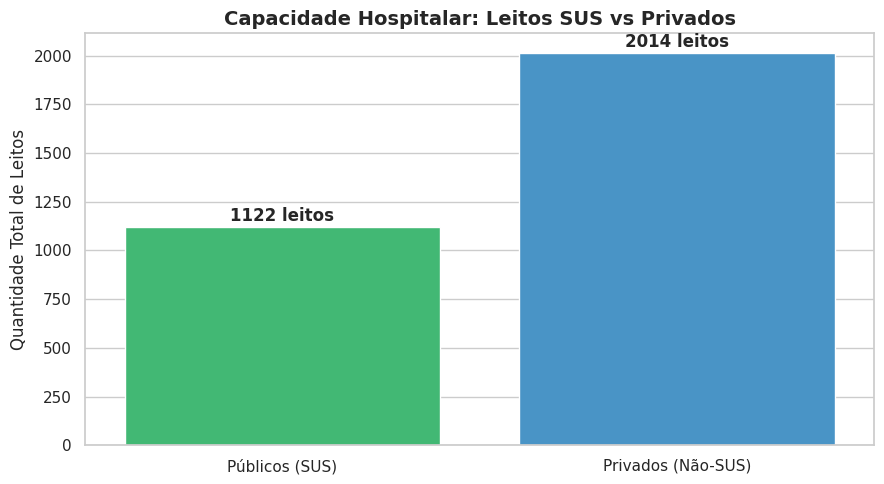

In [9]:
# ==============================================================================
# ETAPA 8: ANÁLISE DE CAPACIDADE HOSPITALAR E INDICADOR DA OMS
# ==============================================================================

print("--- RAIO-X DA CAPACIDADE HOSPITALAR DE NITERÓI ---\n")

# 1. Tratamento numérico dos dados do CNES (Leitos)
df_leitos['QT_SUS'] = pd.to_numeric(df_leitos['QT_SUS'], errors='coerce').fillna(0)
df_leitos['QT_NSUS'] = pd.to_numeric(df_leitos['QT_NSUS'], errors='coerce').fillna(0)

# 2. Cálculos Totais
total_sus = df_leitos['QT_SUS'].sum()
total_privado = df_leitos['QT_NSUS'].sum()
total_leitos = total_sus + total_privado
populacao_total = df_niteroi['POPULACAO'].sum()

# 3. Métrica Ouro (Taxa OMS por mil habitantes)
taxa_oms = (total_leitos / populacao_total) * 1000

print(f"População Total: {int(populacao_total):,}".replace(',', '.'))
print(f"Total de Leitos na cidade: {int(total_leitos):,}".replace(',', '.'))
print(f"➔ INDICADOR OMS ALCANÇADO: {taxa_oms:.2f} leitos para cada 1.000 habitantes.\n")

if taxa_oms >= 3:
    print("STATUS: ✅ DENTRO/ACIMA da meta recomendada pela Organização Mundial da Saúde (3 a 5)")
else:
    print("STATUS: ❌ ABAIXO da meta recomendada pela Organização Mundial da Saúde (3 a 5)")

# 4. Gráfico Final
plt.figure(figsize=(9, 5))
# Passar 'x' para 'hue' e usar legend=False para adequação ao novo padrão do Seaborn
ax = sns.barplot(
    x=['Públicos (SUS)', 'Privados (Não-SUS)'],
    y=[total_sus, total_privado],
    hue=['Públicos (SUS)', 'Privados (Não-SUS)'],
    palette=['#2ecc71', '#3498db'],
    legend=False
)

plt.title('Capacidade Hospitalar: Leitos SUS vs Privados', fontsize=14, fontweight='bold')
plt.ylabel('Quantidade Total de Leitos', fontsize=12)

# Adicionando os valores em cima das barras
for i, valor in enumerate([total_sus, total_privado]):
    plt.text(i, valor + 30, f'{int(valor)} leitos', ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()